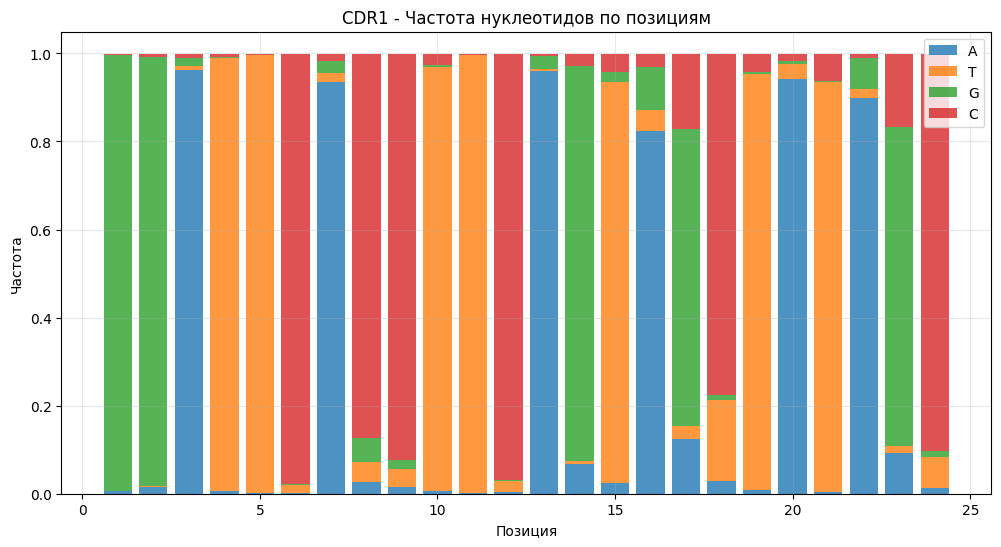

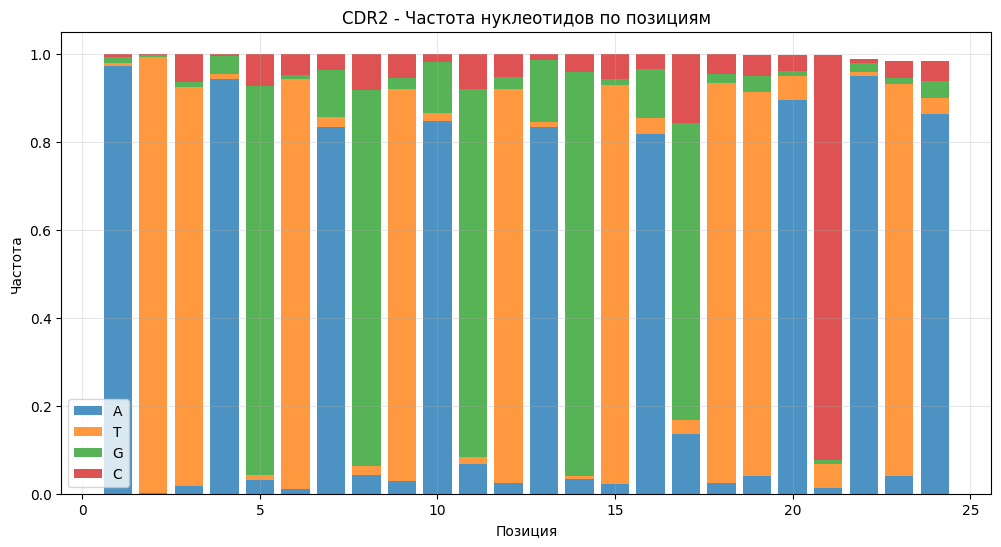

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/Users/veronikaaksinina/Downloads/all_ighv3-21_cdr_data.csv")

cdr1 = df.iloc[:, 0]  # CDR1
cdr2 = df.iloc[:, 2]  # CDR2

def plot_nucleotide_freq(sequences, title):
    seq_len = len(sequences.iloc[0])
    nucleotides = ['A', 'T', 'G', 'C']
    freq_data = []
    for pos in range(seq_len):
        pos_bases = sequences.str[pos]
        counts = [pos_bases.str.count(nt).sum() for nt in nucleotides]
        total = len(sequences)
        freqs = [c/total for c in counts]
        freq_data.append(freqs)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = range(1, seq_len + 1)
    bottom = np.zeros(seq_len)
    
    for i, nt in enumerate(nucleotides):
        values = [freq_data[pos][i] for pos in range(seq_len)]
        ax.bar(x, values, bottom=bottom, label=nt, alpha=0.8)
        bottom = [bottom[j] + values[j] for j in range(seq_len)]
    
    ax.set_xlabel('Позиция')
    ax.set_ylabel('Частота')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.show()

plot_nucleotide_freq(cdr1, "CDR1 - Частота нуклеотидов по позициям")
plot_nucleotide_freq(cdr2, "CDR2 - Частота нуклеотидов по позициям")

In [23]:
import pandas as pd

def create_frequency_table(sequences, name):
    seq_len = len(sequences.iloc[0])
    nucleotides = ['A', 'T', 'G', 'C']
    freq_table = pd.DataFrame(index=nucleotides, columns=[f'Pos{i+1}' for i in range(seq_len)])
    for pos in range(seq_len):
        pos_bases = sequences.str[pos]
        total = len(sequences)
        for nt in nucleotides:
            count = pos_bases.str.count(nt).sum()
            freq = count / total
            freq_table.loc[nt, f'Pos{pos+1}'] = f"{freq:.3f}"
    
    print(f"\n{name} - Таблица частот нуклеотидов:")
    print(freq_table)
    return freq_table

cdr1_table = create_frequency_table(cdr1, "CDR1")
cdr2_table = create_frequency_table(cdr2, "CDR2")


CDR1 - Таблица частот нуклеотидов:
    Pos1   Pos2   Pos3   Pos4   Pos5   Pos6   Pos7   Pos8   Pos9  Pos10  ...  \
A  0.006  0.016  0.963  0.007  0.002  0.002  0.934  0.026  0.015  0.005  ...   
T  0.001  0.001  0.009  0.983  0.994  0.017  0.021  0.045  0.042  0.964  ...   
G  0.991  0.976  0.016  0.003  0.001  0.004  0.027  0.055  0.020  0.004  ...   
C  0.002  0.007  0.011  0.007  0.002  0.976  0.017  0.872  0.923  0.026  ...   

   Pos15  Pos16  Pos17  Pos18  Pos19  Pos20  Pos21  Pos22  Pos23  Pos24  
A  0.023  0.823  0.124  0.030  0.008  0.942  0.003  0.899  0.093  0.013  
T  0.913  0.048  0.029  0.184  0.945  0.035  0.933  0.022  0.016  0.070  
G  0.021  0.098  0.675  0.011  0.004  0.006  0.002  0.068  0.723  0.015  
C  0.042  0.030  0.171  0.774  0.042  0.016  0.061  0.010  0.167  0.901  

[4 rows x 24 columns]

CDR2 - Таблица частот нуклеотидов:
    Pos1   Pos2   Pos3   Pos4   Pos5   Pos6   Pos7   Pos8   Pos9  Pos10  ...  \
A  0.972  0.002  0.019  0.941  0.032  0.010  0.834  0.

In [24]:
# Сохраняем таблицы в CSV
cdr1_table.to_csv("cdr1_nucleotide_frequencies.csv")
cdr2_table.to_csv("cdr2_nucleotide_frequencies.csv")

print("Таблицы сохранены:")
print("- cdr1_nucleotide_frequencies.csv")
print("- cdr2_nucleotide_frequencies.csv")

Таблицы сохранены:
- cdr1_nucleotide_frequencies.csv
- cdr2_nucleotide_frequencies.csv


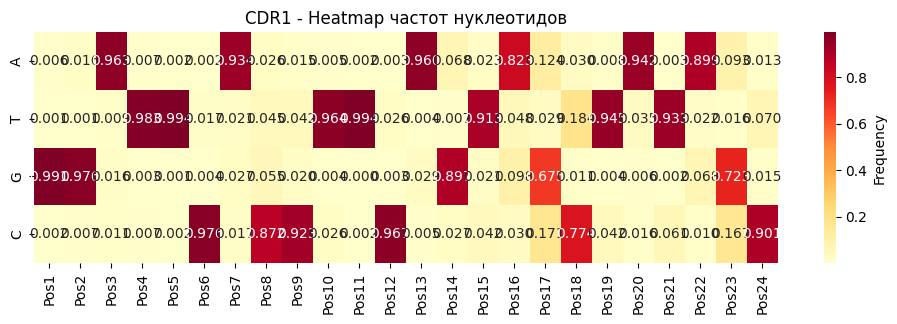

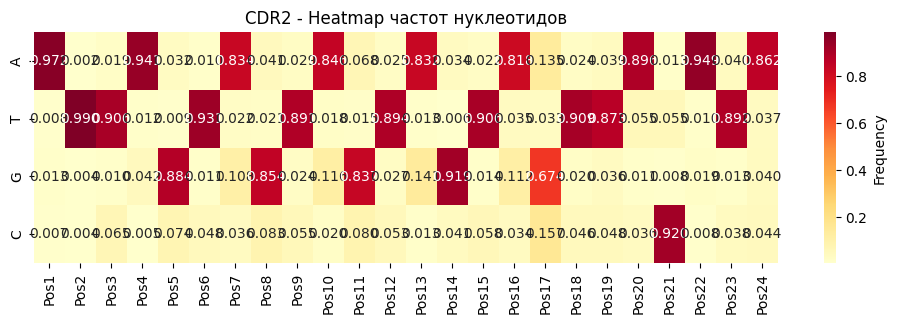

In [25]:
import seaborn as sns

def plot_heatmap(sequences, title):
    seq_len = len(sequences.iloc[0])
    nucleotides = ['A', 'T', 'G', 'C']

    freq_matrix = []
    for pos in range(seq_len):
        pos_bases = sequences.str[pos]
        total = len(sequences)
        freqs = [pos_bases.str.count(nt).sum() / total for nt in nucleotides]
        freq_matrix.append(freqs)

    freq_matrix = np.array(freq_matrix).T

    plt.figure(figsize=(12, 3))
    sns.heatmap(freq_matrix, 
                xticklabels=[f'Pos{i+1}' for i in range(seq_len)],
                yticklabels=nucleotides,
                annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Frequency'})
    plt.title(title)
    plt.show()

plot_heatmap(cdr1, "CDR1 - Heatmap частот нуклеотидов")
plot_heatmap(cdr2, "CDR2 - Heatmap частот нуклеотидов")